## Flujo en cadena (02 -> 03)

1. Agente 2 valida archivos nuevos y genera:

- quotes_agent_strict_events.csv
- retry_queue.parquet/csv (files a redescargar)
- state.json

2. Si retry_queue no está vacío:

- se ejecuta redescarga de esos files
- vuelve a correr Agente 2 sobre esos redescargados

3. Solo cuando retry esté limpio o congelado por límite de reintentos:

- arranca Agente 3 (stats/cobertura final incremental)

4. Agente 3 recalcula métricas usando el output validado de Agente 2:

- cobertura por ticker
- faltantes por día
- % pass / soft / hard
- resumen operativo

———

## Qué haría el Agente 3 con tu data actual

Entradas:

- C:\TSIS_Data\data\quotes_p95 (o D:\Data_polygon\quotes)
- quotes_agent_strict_events.csv
- quotes_agent_strict_state.json
- retry_queue (si existe)
- ventana oficial (official_lifecycle_compiled.csv)

Salidas:

- coverage_by_ticker.parquet/csv
- missing_days_by_ticker.parquet/csv
- quality_summary_by_ticker.parquet/csv
- run_summary.json

———

## Celdas (paso a paso, validando tú)

1. Celda A: cargar rutas y parámetros (MAX_TICKERS, DATE_FROM/TO, STRICT_ONLY=True/False).
2. Celda B: leer eventos del Agente 2 + limpiar duplicados por file (último estado).
3. Celda C: construir estado por día (PASS, SOFT_FAIL, HARD_FAIL, RETRY_PENDING).
4. Celda D: cruzar contra ventana oficial por ticker y calcular cobertura.
5. Celda E: generar tablas y gráficos (top faltantes, top warns, cobertura hist).
6. Celda F: gate de cadena:

- si hay RETRY_PENDING -> “NO cerrar corrida”
- si no hay -> “corrida cerrada”

———

## Regla clave para tu requisito de re-descarga

En Agente 3, un día/ticker con HARD_FAIL o RETRY_PENDING no cuenta cobertura hasta que:

- redescarga OK
- Agente 2 lo revalida en PASS o SOFT_FAIL

---


**Diferencia:**

**- Agente 02:**
    - evalúa archivo por archivo (calidad/estado).
    - escribe events y retry_queue.
    
**- Agente 03:**
    - consolida cobertura final por ticker/día.
    - decide si la corrida se puede cerrar.
    - verifica coherencia del sistema completo.

Por eso tiene sentido que 03 haga chequeo extra:

- files_en_events vs files_en_quotes_root
- missing_in_disk (evento dice que existe, pero no está en disco)
- missing_in_events (archivo en disco que 02 aún no validó)

No es duplicar; es auditoría de integridad del pipeline.

In [38]:
# =========================
# Agente 03 (stats/cobertura) para la MISMA corrida del 02
# =========================

from pathlib import Path

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit")
RUN_DIR = max([p for p in BASE.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)

QUOTES_ROOT = Path(r"C:\TSIS_Data\data\quotes_p95")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"
OFFICIAL_LIFECYCLE_CSV = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv")
OUT_DIR = RUN_DIR / "agent03_outputs"

MIN_COVERAGE_TO_PASS = 0.95
COVERAGE_OK_STATUSES = ["PASS", "SOFT_FAIL"]

print("RUN_DIR usado:", RUN_DIR)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\036_agent3_quotes_coverage_and_causes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

RUN_DIR usado: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260304_192502_quotes
Run summary:
{
  "events_rows_dedup": 1000,
  "tickers": 8,
  "retry_pending_files": 735,
  "hard_fail_files": 0,
  "mean_coverage_ok": 0.04413481518879127,
  "gate_status": "NO_CLOSE_RETRY_PENDING",
  "min_coverage_to_pass": 0.95,
  "out_dir": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\runs\\polygon_realtime_audit\\20260304_192502_quotes\\agent03_outputs"
}

Ticker diagnosis (por que no pasa):


,ticker,ticker_gate_status,exp_min,exp_max,expected_days,present_days,present_ok_days,missing_days_ok,coverage_ratio_ok,RETRY_PENDING,HARD_FAIL,SOFT_FAIL,cause,count,definicion
7,AAIC,LOW_COVERAGE,2021-06-25,2023-05-30,705,2,2,703,0.002837,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
1,AAC,LOW_COVERAGE,2021-09-10,2023-06-30,659,11,11,648,0.016692,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
2,AACI,LOW_COVERAGE,2026-02-17,2025-10-20,0,1,1,0,NaN,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
4,AACT,NO_CLOSE_RETRY_PENDING,2023-08-25,2025-05-30,645,12,9,636,0.013953,3,0,0,crossed_ratio_gt_threshold,3.0,Porcentaje de bid>ask supera el umbral estricto.
5,AAGR,NO_CLOSE_RETRY_PENDING,2023-12-19,2024-09-26,283,13,5,278,0.017668,8,0,0,crossed_rows_present_but_under_threshold,5.0,"Hay bid>ask, pero por debajo del umbral."
3,AACQ,NO_CLOSE_RETRY_PENDING,2020-10-01,2021-06-24,267,34,7,260,0.026217,27,0,0,crossed_rows_present_but_under_threshold,21.0,"Hay bid>ask, pero por debajo del umbral."
6,AAI,NO_CLOSE_RETRY_PENDING,2004-01-05,2011-03-08,2620,746,186,2434,0.070992,560,0,0,crossed_rows_present_but_under_threshold,324.0,"Hay bid>ask, pero por debajo del umbral."
0,AABA,NO_CLOSE_RETRY_PENDING,2019-01-02,2019-10-02,274,181,44,230,0.160584,137,0,0,crossed_rows_present_but_under_threshold,135.0,"Hay bid>ask, pero por debajo del umbral."



Top causas globales:


,cause,cause_type,count,definicion
1,crossed_rows_present_but_under_threshold,warn,485,"Hay bid>ask, pero por debajo del umbral."
0,crossed_ratio_gt_threshold,issue,243,Porcentaje de bid>ask supera el umbral estricto.
2,dtype_mismatch,warn,7,Tipo de dato distinto al esperado.
3,missing_required_columns,issue,1,Faltan columnas requeridas del esquema estricto.
4,zero_rows,issue,1,Parquet leido pero sin filas.


RUN_DIR usado: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260304_192502_quotes

Leyenda de causas:


,cause,tipo,definicion
0,parquet_unreadable,HARD_FAIL,El parquet no se puede abrir/leer.
1,zero_byte_file,HARD_FAIL,Archivo de 0 bytes.
2,invalid_partition_path,HARD_FAIL,Ruta no cumple patron ticker/year/month/day/quotes.parquet.
3,zero_rows,HARD_FAIL,Parquet leido pero sin filas.
4,missing_required_columns,HARD_FAIL,Faltan columnas requeridas del esquema estricto.
5,negative_prices_any_row,HARD_FAIL,Hay filas con bid/ask negativos.
6,crossed_ratio_gt_threshold,HARD_FAIL,Porcentaje de bid>ask supera el umbral estricto.
7,dtype_mismatch,SOFT_FAIL,Tipo de dato distinto al esperado.
8,crossed_rows_present_but_under_threshold,SOFT_FAIL,"Hay bid>ask, pero por debajo del umbral."
9,soft_rule_eval_error,SOFT_FAIL,Error evaluando regla soft; archivo no necesariamente corrupto.



Resumen por severidad (events):


,severity,count
0,HARD_FAIL,244
1,PASS,265
2,SOFT_FAIL,491



Ticker diagnosis (por que no pasa):


,ticker,ticker_gate_status,RETRY_PENDING,HARD_FAIL,SOFT_FAIL,cause,count,definicion
1,AAC,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
2,AACI,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
7,AAIC,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
0,AABA,NO_CLOSE_RETRY_PENDING,137,0,0,crossed_rows_present_but_under_threshold,135.0,"Hay bid>ask, pero por debajo del umbral."
3,AACQ,NO_CLOSE_RETRY_PENDING,27,0,0,crossed_rows_present_but_under_threshold,21.0,"Hay bid>ask, pero por debajo del umbral."
4,AACT,NO_CLOSE_RETRY_PENDING,3,0,0,crossed_ratio_gt_threshold,3.0,Porcentaje de bid>ask supera el umbral estricto.
5,AAGR,NO_CLOSE_RETRY_PENDING,8,0,0,crossed_rows_present_but_under_threshold,5.0,"Hay bid>ask, pero por debajo del umbral."
6,AAI,NO_CLOSE_RETRY_PENDING,560,0,0,crossed_rows_present_but_under_threshold,324.0,"Hay bid>ask, pero por debajo del umbral."



Cobertura temporal por ticker:


,ticker,exp_min,exp_max,expected_days,present_days,present_ok_days,missing_days_ok,coverage_ratio_ok
7,AAIC,2021-06-25,2023-05-30,705,2,2,703,0.002837
4,AACT,2023-08-25,2025-05-30,645,12,9,636,0.013953
1,AAC,2021-09-10,2023-06-30,659,11,11,648,0.016692
5,AAGR,2023-12-19,2024-09-26,283,13,5,278,0.017668
3,AACQ,2020-10-01,2021-06-24,267,34,7,260,0.026217
6,AAI,2004-01-05,2011-03-08,2620,746,186,2434,0.070992
0,AABA,2019-01-02,2019-10-02,274,181,44,230,0.160584
2,AACI,2026-02-17,2025-10-20,0,1,1,0,NaN


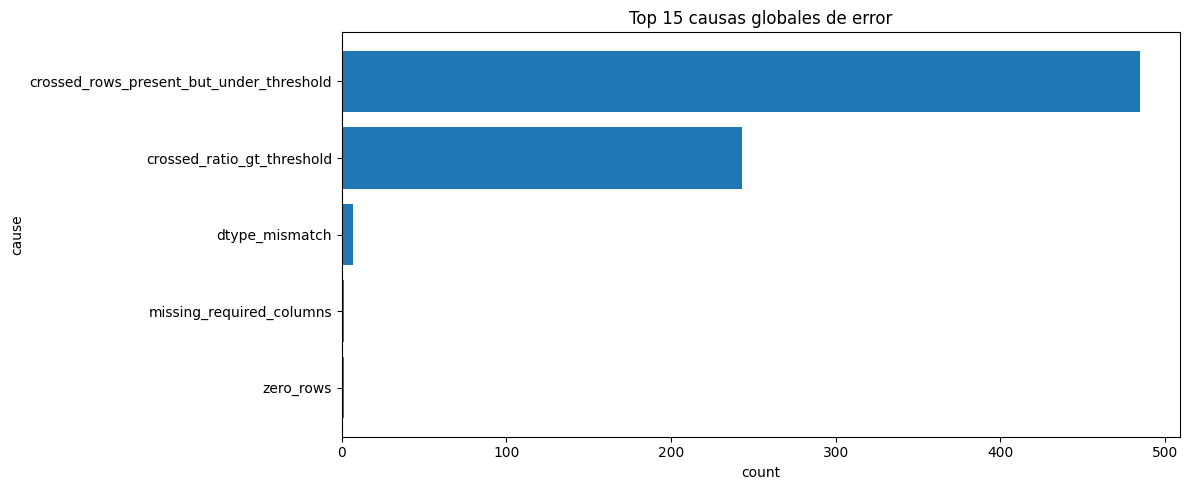

In [39]:
from pathlib import Path

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit")
RUN_DIR = max([p for p in BASE.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)

OUT_DIR = RUN_DIR / "agent03_outputs"
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
TOP_N = 15
FIGSIZE = (12, 5)

print("RUN_DIR usado:", RUN_DIR)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\037_agent3_diagnostics_tables_hist.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

In [40]:
from pathlib import Path

RUN_ID = "20260304_184355_quotes"
RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit") / RUN_ID

EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
TOP_N = 20

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\038_bid_ask_cross_deviation_metrics.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())


Metricas globales de desviacion bid>ask:


,metric,value
0,files_total,1.000000e+03
1,files_with_cross,7.280000e+02
2,files_with_cross_pct,7.280000e+01
3,rows_total,3.863547e+07
4,crossed_rows_total,6.226100e+04
5,weighted_crossed_ratio_pct,1.611499e-01
6,p50_file_crossed_ratio_pct,3.184656e-02
7,p90_file_crossed_ratio_pct,4.786349e-01
8,p95_file_crossed_ratio_pct,9.877873e-01
9,p99_file_crossed_ratio_pct,2.505554e+00



Top 20 tickers por desviacion (weighted_crossed_ratio_pct):


,ticker,files,rows_total,crossed_rows_total,mean_file_crossed_ratio_pct,p95_file_crossed_ratio_pct,max_file_crossed_ratio_pct,weighted_crossed_ratio_pct
3,AACQ,34,1033169,38062,2.927688,0.395588,97.453240,3.684005
4,AACT,12,6738,19,0.694641,3.875616,5.000000,0.281983
5,AAGR,13,56150,130,0.170757,0.833283,1.605652,0.231523
6,AAI,746,12298105,22425,0.251270,1.198780,4.719764,0.182345
0,AABA,181,25212819,1625,0.008121,0.036735,0.104526,0.006445
1,AAC,11,9871,0,0.000000,0.000000,0.000000,0.000000
2,AACI,1,928,0,0.000000,0.000000,0.000000,0.000000
7,AAIC,2,17686,0,0.000000,0.000000,0.000000,0.000000



Top 20 archivos por crossed_ratio_pct:


,ticker,year,month,day,rows,crossed_rows,crossed_ratio_pct,severity,file
195,AACQ,2021,02,25,38441,37462,97.453240,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AACQ\year=2021\mo...
218,AACT,2024,08,26,120,6,5.000000,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AACT\year=2024\mo...
286,AAI,2005,01,05,3051,144,4.719764,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2005\mon...
274,AAI,2004,06,29,1469,55,3.744044,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2004\mon...
407,AAI,2007,02,27,15295,475,3.105590,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2007\mon...
217,AACT,2024,05,02,203,6,2.955665,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AACT\year=2024\mo...
958,AAI,2010,11,02,4322,125,2.892180,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2010\mon...
584,AAI,2008,09,16,33026,892,2.700902,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2008\mon...
756,AAI,2009,10,14,19939,534,2.678168,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2009\mon...
260,AAI,2004,02,04,1510,38,2.516556,HARD_FAIL,C:\TSIS_Data\data\quotes_p95\AAI\year=2004\mon...
